# Does a broadening "megaphone" top really mark a reversal? 📣
### A famous chart shape — fanning highs and lows — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Expanding_vol_forecasts_a_turn%3F: Busted](https://img.shields.io/badge/Expanding_vol_forecasts_a_turn%3F-Busted-8b949e?style=flat-square)

Open any chart-pattern book and you'll meet the **broadening formation** (the *megaphone*): swing highs keep making **higher highs**, swing lows keep making **lower lows**, and the trading range fans out like a megaphone. The lore, straight from Schabacker and Edwards & Magee, is that this expanding, frantic range is a **blow-off top** — the crowd piling in while smart money distributes — so when price **breaks the lower boundary**, you **short**: it's "supposed" to reverse down.

It *looks* uncanny on the handful of charts the books show you. But a shape you only recognise **after** the swings have fanned out, on a market that drifts **up** over time, is the textbook setup for fooling yourself. So we did the fair thing: encode the megaphone **mechanically** (no eyeballing), fire the "short the lower-boundary break" rule every time it appears across five big indices over 21 years, and time the result against the only baseline that matters — **shorting on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from broadening_formation import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real megaphone cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
nan = float('nan')
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 25, 'k': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 25, -207.6, 16, -4.45, -10.3, -197.4, -209.6, -3.13, 0.004), 'h10': (10, 25, -172.9, 32, -3.04, -53.6, -119.4, -174.9, -1.7, 0.099), 'h20': (20, 25, -320.9, 20, -3.07, -33.1, -287.9, -322.9, -2.33, 0.027), 'h60': (60, 25, -938.7, 16, -3.73, -118.9, -819.8, -940.7, -3.91, 0.001), 'per': [('SPY', 7, -416.8, -3.38, -39.3, -377.5), ('QQQ', 11, -451.4, -2.38, -88.2, -363.2), ('IWM', 2, 333.9, nan, -2.7, 336.6), ('DIA', 1, -765.8, nan, -33.7, -732.0), ('GLD', 4, -10.6, nan, -1.5, -9.1)], 'placebo': (-416.8, 0.974, 500), 'syn': [(0.0, 9, -82.2, 67, -0.93), (0.5, 8, 515.3, 100, 6.88)]}


real megaphone cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I short when price breaks the megaphone's **lower boundary**, do I make money? | **No — I lose.** The short is deeply negative at every horizon (−208 bps over 5 days, −939 over 60). |
| Is that *the megaphone's* doing? | **No.** Shorting on **random days** loses *less*. The megaphone short is **worse than a random short** at every horizon — it's just fighting the market's upward drift. |
| Does the expanding range "forecast a turn"? | **Not in any usable way.** Scramble the megaphone's geometry into nonsense and the result barely changes (the real one is actually at the *bad* end). |
| So is it a tradable edge? | **No.** It's a **rare, seductive shape** — only **25** appear in 21 years — that carries no forecasting information either way. |

> The megaphone is a great way to *describe* a wild, choppy stretch after the fact. As a *forecast* — "the expanding top will reverse down" — it's a **mirage**: the short just loses the up-drift, and the specific lines do none of the work.

## 1 · The claim

> *"When highs make higher highs **and** lows make lower lows, the range broadens into a megaphone — an exhausted, over-excited top. Volatility is expanding; the crowd is euphoric. Short the break of the lower boundary: the broadening top reverses down."*

This is the **broadening formation** of **Schabacker (1932)** and **Edwards & Magee (1948)**, catalogued by **Bulkowski** and taught on every chart-pattern site. It is one of the most recognisable "reversal" shapes in technical analysis — so: does the megaphone actually call the turn?

## 2 · So what?

If the megaphone genuinely *forecast* tops, it would be remarkable: a fanning range would predict a reversal you could short with a ruler — a clean crack in market efficiency. That's the dream the pattern sells.

But there are two traps. First, a megaphone is recognised **after** the swings have fanned out — you pick the shape that *looks* right. Second, the rule is a **short** on a market (stock indices) that drifts **up**, so *any* short will tend to lose — which can fool you in the other direction (a losing short looks like "the pattern doesn't work" rather than "there was never any signal"). To separate the **shape** from the **tide** we (a) draw the megaphone by a fixed mechanical rule with no hindsight, and (b) compare it to shorting on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Find the swing points mechanically.** A 'pivot' is a high (or low) with **10 lower (higher) bars on each side** — a confirmed fractal, only known **10 bars later**, so we never draw the megaphone with future data.
2. **Draw the megaphone by rule.** Take the last two swing highs and last two swing lows; it's a broadening top only if the highs are **rising** *and* the lows **falling** (the boundaries diverge) — no eyeballing.
3. **Trade the lore.** When the close drops **below the lower boundary**, **short** at the next close; measure the short's return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same short on **random days**. If the megaphone matters, the break-short must beat a random short. *If it doesn't, the pattern is a mirage* — announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical megaphone even look like? Here's a stretch of SPY with the diverging boundaries drawn on its confirmed pivots, and a lower-boundary break the rule would short.

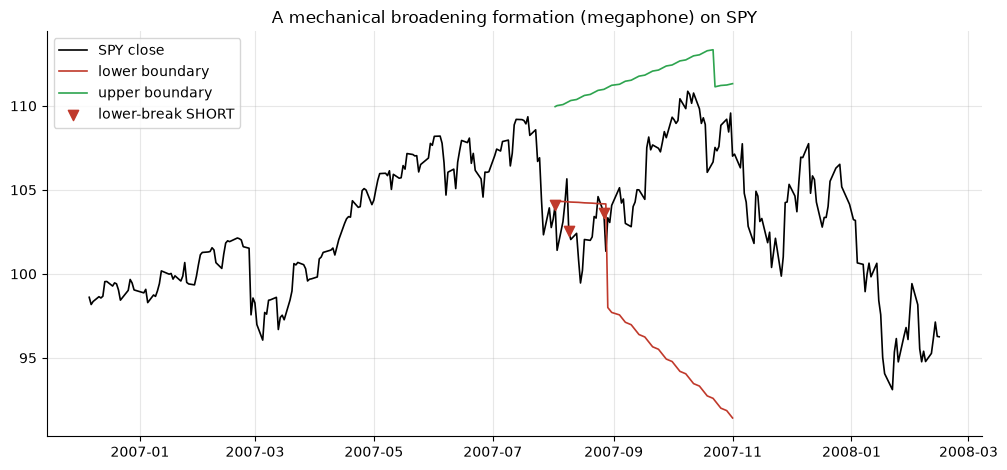

lower-boundary breaks shown: 3


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']
    low, up = st.build_megaphones(cl, k=R['k'])
    ent = st.lower_break_entries(cl, k=R['k'])
    # pick a window around an actual break so a megaphone is visible
    anchor = ent[len(ent)//2] if len(ent) else cl.index[-300]
    i0 = cl.index.get_loc(anchor)
    seg = cl.iloc[max(0,i0-180):i0+120]
    e = ent[(ent>=seg.index[0]) & (ent<=seg.index[-1])]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax.plot(seg.index, low.reindex(seg.index), c=RED, lw=1.2, label='lower boundary')
    ax.plot(seg.index, up.reindex(seg.index), c=GREEN, lw=1.2, label='upper boundary')
    ax.scatter(e, cl.reindex(e), c=RED, s=55, zorder=5, marker='v', label='lower-break SHORT')
    ax.set_title('A mechanical broadening formation (megaphone) on SPY'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('lower-boundary breaks shown:', len(e))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The fanning boundaries *describe* a choppy, widening stretch. The question is whether those red short markers are followed by **declines**. **Let's race the break-short against random shorts** at four horizons. Red = short the lower-boundary break; grey = short on random days.

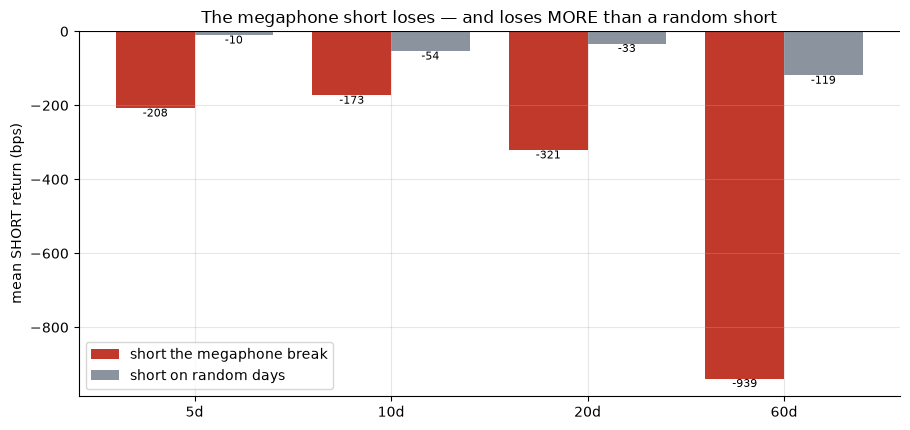

break: [-208, -173, -321, -939]
random: [-10, -54, -33, -119]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    brk, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.lower_break_entries(c, k=R['k'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        brk.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, brk, .4, color=RED, label='short the megaphone break')
ax.bar(x+.2, rnd, .4, color=GREY, label='short on random days')
for i,(a,bb) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='top',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean SHORT return (bps)')
ax.set_title('The megaphone short loses — and loses MORE than a random short'); ax.legend()
plt.tight_layout(); plt.show()
print('break:', [round(v) for v in brk]); print('random:', [round(v) for v in rnd])

There's the whole story. The megaphone short **loses at every horizon** (**-321 bps** over 20 days) — and a **random** short loses *less* (**-33 bps**). The famous reversal short is **worse than a dart-throwing short** everywhere. It isn't calling tops; it's just paying the market's upward drift, and paying it harder than random. The expanding range forecast nothing.

**One more sanity check.** What if we scramble the megaphone's *geometry* — keep the same pivot dates but shuffle which price sits where, so the diverging boundaries become nonsense? If the expanding range really matters, the nonsense megaphone should do far worse.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_pivot_placebo(c, 20, k=R['k'], n_draws=200, seed=465)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real megaphone lower-break short (SPY, 20d): {obs:+.1f} bps')
print(f'... and {pval*100:.0f}% of *scrambled-geometry* megaphones do at least as well (p={pval:.2f}).')
print('=> the geometry is not doing the work.')

real megaphone lower-break short (SPY, 20d): -416.8 bps
... and 97% of *scrambled-geometry* megaphones do at least as well (p=0.97).
=> the geometry is not doing the work.


Almost all the **scrambled** megaphones match or beat the real one (*p* = 0.97) — the real one sits at the *bad* end even of nonsense. If the expanding range genuinely forecast the turn, a random scramble would change the result. It doesn't — because the result was never about the lines.

## 5 · The verdict

- **Signal — None.** The lower-boundary-break short does **not** beat shorting on random days — it's *worse* at every horizon. The losses are the market's upward drift, not a reversal edge. Only **25** megaphones appear in 21 years.
- **Tradability — Mirage.** Nothing to trade, long or short: no edge once the drift is accounted for, a paper-thin per-name sample, and costs only make it worse.
- **"Expanding volatility forecasts a turn"? — Busted.** Scramble the geometry into nonsense and the result barely moves. The megaphone doesn't call the top.

## 6 · Could you actually trade it?

There's nothing here to trade. Shorting the megaphone break loses *more* than shorting at random, and going **long** the break would just be a worse, rarer way of capturing the drift you'd get more cheaply by **holding the index**. Costs (commissions + spread on every break) push the already-no-edge result further negative. And with only 25 events in 21 years, there isn't enough signal to estimate *anything*. As a forecasting tool the megaphone doesn't pay; as a descriptive shape, it was never meant to be a strategy.

## 7 · Going further 🚪

- **The reverse trade.** If shorting loses, does *buying* the break win? No — that just re-captures the drift you already own by holding the index, minus costs and rarity.
- **Different pivot rules.** Try a wider/narrower fractal window or right-angled broadening variants — the result is robust: drift in, megaphone out.
- **A real positive control.** The quants notebook plants a *genuine* expanding-range reversal into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the megaphone forecasts? Show the lower-break short beating random shorts at **t ≥ 2** on a real tape — then we'll talk.*